<a href="https://colab.research.google.com/github/siquette/IAD-004-2025-2/blob/main/IAD_004_Y2025_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font face="Verdana" size=6 color='#6495ED'> IAD-004 AULA 07: PVA
<font face="Verdana" size=3 color='#40E0D0'> Professores Larissa Driemeier e Thiago Martins

<center><img src='https://drive.google.com/uc?export=view&id=1sRJW7uRq_SqpfXEcMNwdaA9MQCj1V1qx' width="600"></center>

Este notebook introdutório é sobre problemas de Regressão, baseado na primeira aula [IAD-004](https://alunoweb.net/moodle/pluginfile.php/157646/mod_resource/content/2/Aula07_PCA_Y2025.pdf), ano 2025.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

# Teoria de Análise de Componentes Principais (PCA)

## Introdução
A Análise de Componentes Principais (PCA) é uma técnica de redução de dimensionalidade que transforma variáveis correlacionadas em um conjunto menor de variáveis não correlacionadas (componentes principais).

## Pressupostos
 - Linearidade: PCA assume relações lineares entre variáveis
 - Média zero: Dados devem estar centralizados ($\mu = 0$)
 - Variância importante: Variáveis com maior variância têm maior influência



## 1. Centralização dos Dados

Dada uma matriz $X \in \mathbb{R}^{n \times p}$ com $n$ amostras e $p$ variáveis:

$$
X_c = X - \bar{X}, \quad \text{onde} \quad \bar{X} = \frac{1}{n}\sum_{i=1}^n X_i
$$



Por exemplo,
 $$
 X = \begin{bmatrix}
 10 & 5 \\
 20 & 15 \\
 30 & 25 \\
 \end{bmatrix}
 $$

$$
 \bar{X} = \left[ \frac{10+20+30}{3} = 20,\ \frac{5+15+25}{3} = 15 \right]
 $$

A matriz Centralizada $X_c$ (X - média) é dada por,
$$
 X_c = X - \bar{X} = \begin{bmatrix}
 10-20 & 5-15 \\
 20-20 & 15-15 \\
 30-20 & 25-15 \\
 \end{bmatrix} = \begin{bmatrix}
 -10 & -10 \\
 0 & 0 \\
 10 & 10 \\
 \end{bmatrix}
$$

In [3]:
# Matriz de dados original X (3 amostras, 2 variáveis)
X = np.array([
    [10, 5],
    [20, 15],
    [30, 25]
])

# 1. Cálculo da média de cada variável
mean_X = np.mean(X, axis=0)  # axis=0 calcula por coluna (variáveis)
print("Média das características:", mean_X)

# 2. Centralização dos dados (Xc = X - X̄)
X_centered = X - mean_X
print("\nMatriz centralizada (Xc):\n", X_centered)

# 3. Verificação: média de Xc deve ser próxima de zero
print("\nMédia de Xc (deve ser aprox 0):", np.mean(X_centered, axis=0))

Média das características: [20. 15.]

Matriz centralizada (Xc):
 [[-10. -10.]
 [  0.   0.]
 [ 10.  10.]]

Média de Xc (deve ser aprox 0): [0. 0.]


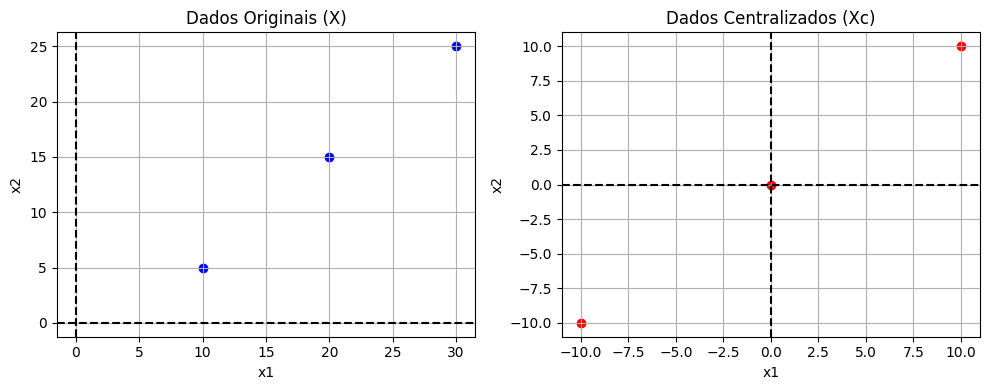

In [4]:
plt.figure(figsize=(10, 4))

# Dados originais
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], color='blue')
plt.title("Dados Originais (X)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.grid()

# Dados centralizados
plt.subplot(1, 2, 2)
plt.scatter(X_centered[:, 0], X_centered[:, 1], color='red')
plt.title("Dados Centralizados (Xc)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.grid()

plt.tight_layout()
plt.show()

### Exemplo
Temos a matriz de dados original $X$ com 4 amostras e 3 variáveis:

$$
X = \begin{bmatrix}
149 & 48 & 27 \\
155 & 52 & 39 \\
163 & 57 & 45 \\
177 & 68 & 33 \\
\end{bmatrix}
$$

Calculamos a média para cada coluna (variável):

\begin{align*}
\bar{X}_1 &= \frac{149 + 155 + 163 + 177}{4} = \frac{644}{4} = 161 \\
\bar{X}_2 &= \frac{48 + 52 + 57 + 68}{4} = \frac{225}{4} = 56.25 \\
\bar{X}_3 &= \frac{27 + 39 + 45 + 33}{4} = \frac{144}{4} = 36
\end{align*}

Portanto, o vetor de médias é:

$$
\bar{X} = \begin{bmatrix}
161 & 56.25 & 36 \\
\end{bmatrix}
$$

Subtraímos as médias de cada coluna para obter a matriz centralizada $X_c$:

$$
X_c = X - \bar{X} = \begin{bmatrix}
149-161 & 48-56.25 & 27-36 \\
155-161 & 52-56.25 & 39-36 \\
163-161 & 57-56.25 & 45-36 \\
177-161 & 68-56.25 & 33-36 \\
\end{bmatrix}
$$
de modo que a matriz centralizada é:

$$
X_c = \begin{bmatrix}
-12 & -8.25 & -9 \\
-6 & -4.25 & 3 \\
2 & 0.75 & 9 \\
16 & 11.75 & -3 \\
\end{bmatrix}
$$

Podemos confirmar que a média de cada coluna em $X_c$ é aproximadamente zero:

\begin{align*}
\text{Média coluna 1} &= \frac{-12-6+2+16}{4} = 0 \\
\text{Média coluna 2} &= \frac{-8.25-4.25+0.75+11.75}{4} = 0 \\
\text{Média coluna 3} &= \frac{-9+3+9-3}{4} = 0
\end{align*}

In [5]:
# Matriz original
X = np.array([
    [149, 48, 27],
    [155, 52, 39],
    [163, 57, 45],
    [177, 68, 33]
])

# Cálculo da média
mean_X = np.mean(X, axis=0)
print("Média de cada característica:", mean_X)

# Centralização
X_centered = X - mean_X
print("\nMatriz centralizada (Xc):\n", X_centered)

# Verificação
print("\nMédia de Xc (deve ser aprox 0):", np.mean(X_centered, axis=0))

Média de cada característica: [161.    56.25  36.  ]

Matriz centralizada (Xc):
 [[-12.    -8.25  -9.  ]
 [ -6.    -4.25   3.  ]
 [  2.     0.75   9.  ]
 [ 16.    11.75  -3.  ]]

Média de Xc (deve ser aprox 0): [0. 0. 0.]


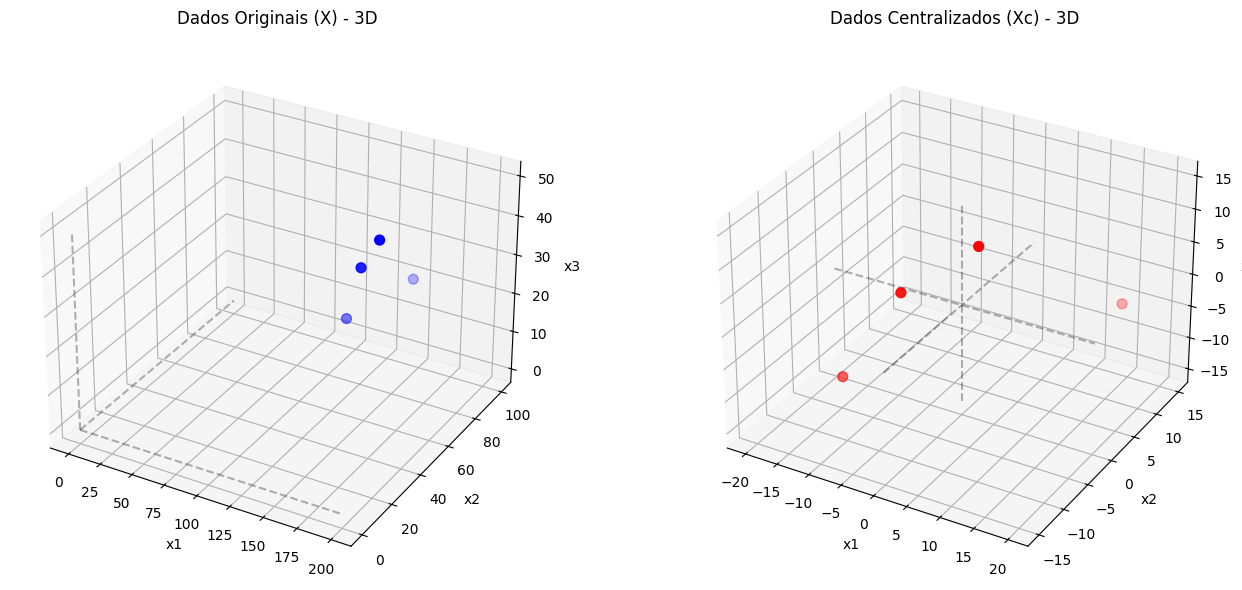

In [6]:
X = np.array([
    [149, 48, 27],
    [155, 52, 39],
    [163, 57, 45],
    [177, 68, 33]
])

# Centralização
X_centered = X - np.mean(X, axis=0)

# Criando figura 3D
fig = plt.figure(figsize=(14, 6))

# Plot 3D dos dados originais
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', s=50)
ax1.set_title("Dados Originais (X) - 3D", pad=15)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("x3")
ax1.grid(True)

# Adicionando planos de referência
ax1.plot([0, 200], [0, 0], [0, 0], 'k--', alpha=0.3)
ax1.plot([0, 0], [0, 100], [0, 0], 'k--', alpha=0.3)
ax1.plot([0, 0], [0, 0], [0, 50], 'k--', alpha=0.3)

# Plot 3D dos dados centralizados
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_centered[:, 0], X_centered[:, 1], X_centered[:, 2], c='red', s=50)
ax2.set_title("Dados Centralizados (Xc) - 3D", pad=15)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("x3")
ax2.grid(True)

# Adicionando planos de referência na origem
ax2.plot([-20, 20], [0, 0], [0, 0], 'k--', alpha=0.3)
ax2.plot([0, 0], [-15, 15], [0, 0], 'k--', alpha=0.3)
ax2.plot([0, 0], [0, 0], [-15, 15], 'k--', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Matriz de Covariância

A matriz de covariância $S$ é calculada como:

$$
S_{jk} = \frac{1}{n-1}\sum_{i=1}^n (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)
$$

Onde:
- $n$ = número de amostras (4)
- $x_{ij}$ = valor da amostra $i$ para a variável $j$
- $\bar{x}_j$ = média da variável $j$

Alternativamente, podemos calcular como:

$$
S = \frac{1}{n-1} X_c^T X_c
$$





In [7]:
cov_matrix = np.cov(X_centered, rowvar=False)

n = X.shape[0]  # número de amostras
cov_matrix_formula = (X_centered.T @ X_centered) / (n - 1)

# Exibição dos resultados
print("Matriz de covariância (np.cov):\n", cov_matrix)
print("\nMatriz via fórmula (X_c^T X_c)/(n-1):\n", cov_matrix_formula)
print("\nDiferença entre os métodos:\n", cov_matrix - cov_matrix_formula)

Matriz de covariância (np.cov):
 [[146.66666667 104.66666667  20.        ]
 [104.66666667  74.91666667  11.        ]
 [ 20.          11.          60.        ]]

Matriz via fórmula (X_c^T X_c)/(n-1):
 [[146.66666667 104.66666667  20.        ]
 [104.66666667  74.91666667  11.        ]
 [ 20.          11.          60.        ]]

Diferença entre os métodos:
 [[ 0.00000000e+00 -1.42108547e-14  0.00000000e+00]
 [-1.42108547e-14 -1.42108547e-14  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]


## 3. Decomposição Espectral

 Resolvemos o problema de autovalores:

$$
S v_i = \lambda_i v_i, \quad i = 1,...,p
$$

- $\lambda_i$: autovalores (ordenados como $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_p \geq 0$)
 - $v_i$: autovetores correspondentes (componentes principais)



### PCA e os autovalores e autovetores

Para fazer a análise de componentes principais, precisamos encontrar os *componentes*, e isso requer a busca de *autovetores* para a matriz de covariância do conjunto de dados.

#### Autovalores e autovetores

Em inglês, autovalores e autovetores chamam-se, respectivamente, *eigenvalues* e *eigenvectors*. Mas, a palavra original é alemã, *eigen*, e significa *próprio, peculiar*. Mas, isso não explica muito. É uma curiosidade.

Os autovetores de uma matriz de covariância são chamados direções principais, pois correspondem às direções da variância máxima. As projeções dos dados nas direções principais são conhecidas como componentes principais.
Daí o nome Análise de Componentes Principais.

Quanto maior o autovalor,  maior a quantidade de variação capturada por aquela componente principal. A variância capturada ao longo de cada CP pode ser calculada pela variância da projeção dos dados na direção principal.

Dado um operador linear $ {\bf A} $ com dimensões $ n \times n $, existe um conjunto de $n$ vetores $ \bf {v}_i $, cada um com a dimensão $n$, de modo que a multiplicação de qualquer um desses vetores por $ {\bf A } $ resulta em um vetor paralelo a $ \bf {v} _i $, com um comprimento multiplicado por uma constante $ \lambda_i $,

$$ {\bf A} \bf {v} _i = \lambda_i \bf {v}_i $$

onde $ \lambda_i $ são os *autovalores* e os vetores $ \bf {v}_i $ são os *autovetores*.

**Importante: autovalores e autovetores são uma característica da matriz ${\bf A}$.** O número de autovalores e autovetores é igual ao rank da matriz.

Use a biblioteca `numpy` para calcular autovalores e autovetores da matriz de covariância que estamos usando como exemplo.
```
autovalores, autovetores = np.linalg.eig(cov)
```
Veja que os autovetores são as colunas da matriz `autovetores`, e referem-se aos autovalores listados no vetor `autovalores`.

In [9]:
autovalores, autovetores = np.linalg.eig(cov)
print('Autovalores:\n',autovalores)
print('Autovetores:\n',autovetores)
print('Autovalor 1: ',autovalores[0],'Autovetor 1:', autovetores[:,0])
print('Autovalor 2: ',autovalores[1],'Autovetor 2:', autovetores[:,1])

NameError: name 'cov' is not defined

### PCA e SVD

Toda matriz simétrica quadrada $\mathbf S $ pode ser diagonalizada através de seus autovalores e autovetores,

$$
\mathbf S = \mathbf V \mathbf \Lambda \mathbf V^T = \sum_{i = 1}^n \lambda_i \mathbf v_i \mathbf v_i^T
$$
onde:
- $V$ contém os autovetores (colunas) sendo que $\mathbf v_i \perp \mathbf v_j, i\neq j$ e $\| \mathbf v_i \| = \mathbf v_i^T \mathbf v_i = 1$.
- $\Lambda$ é diagonal com autovalores $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_n$

A decomposição pode ser explicitada como:

\begin{equation}
\mathbf S_{n \times n} =
\begin{pmatrix}
|  & |  &   & |  \\
\mathbf v_{1} & \mathbf v_{2} & \cdots & \mathbf v_{n} \\
|  & |  &   & |  
\end{pmatrix}
\begin{pmatrix}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots &\vdots \\
0 & 0 & \cdots & \lambda_n
\end{pmatrix} \begin{pmatrix}
-  & \mathbf v_{1}^T  & -  \\
- & \mathbf v_{2}^T & - \\
  & \vdots   &    \\
- & \mathbf v_{n}^T & -
\end{pmatrix}
\end{equation}

\documentclass{article}
\usepackage{amsmath}
\usepackage{mathrsfs}

\begin{document}

Considere a matriz simétrica $\mathbf{S}_{n \times n}$ decomposta como:

\begin{equation}
\mathbf S_{n \times n} =
\begin{pmatrix}
|  & |  &   & |  \\
\mathbf v_{1} & \mathbf v_{2} & \cdots & \mathbf v_{n} \\
|  & |  &   & |  
\end{pmatrix}
\begin{pmatrix}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots &\vdots \\
0 & 0 & \cdots & \lambda_n
\end{pmatrix} \begin{pmatrix}
-  & \mathbf v_{1}^T  & -  \\
- & \mathbf v_{2}^T & - \\
  & \vdots   &    \\
- & \mathbf v_{n}^T & -
\end{pmatrix}
\end{equation}

Vamos desenvolver este produto matricial passo a passo:

\begin{equation}
\mathbf{S} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T =
\begin{pmatrix}
|  & |  &   & |  \\
\mathbf v_{1} & \mathbf v_{2} & \cdots & \mathbf v_{n} \\
|  & |  &   & |  
\end{pmatrix}
\begin{pmatrix}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots &\vdots \\
0 & 0 & \cdots & \lambda_n
\end{pmatrix}
\mathbf{V}^T
\end{equation}

A multiplicação de $\mathbf{V}$ por $\mathbf{\Lambda}$ resulta em:

\begin{equation}
\mathbf{V}\mathbf{\Lambda} =
\begin{pmatrix}
|  & |  &   & |  \\
\lambda_1\mathbf v_{1} & \lambda_2\mathbf v_{2} & \cdots & \lambda_n\mathbf v_{n} \\
|  & |  &   & |  
\end{pmatrix}
\end{equation}

Agora multiplicamos o resultado anterior por $\mathbf{V}^T$:

\begin{equation}
\mathbf{S} =
\begin{pmatrix}
|  & |  &   & |  \\
\lambda_1\mathbf v_{1} & \lambda_2\mathbf v_{2} & \cdots & \lambda_n\mathbf v_{n} \\
|  & |  &   & |  
\end{pmatrix}
\begin{pmatrix}
-  & \mathbf v_{1}^T  & -  \\
- & \mathbf v_{2}^T & - \\
  & \vdots   &    \\
- & \mathbf v_{n}^T & -
\end{pmatrix}
\end{equation}

Esta multiplicação pode ser expressa como uma soma de matrizes de posto 1:

\begin{equation}
\mathbf{S} = \sum_{i=1}^n \lambda_i \mathbf{v}_i \mathbf{v}_i^T
\end{equation}

onde cada termo $\mathbf{v}_i \mathbf{v}_i^T$ é uma matriz $n \times n$ resultante do produto externo do autovetor $\mathbf{v}_i$ por si mesmo.


Cada produto externo $\mathbf{v}_i \mathbf{v}_i^T$ é dado por:

\begin{equation}
\mathbf{v}_i \mathbf{v}_i^T =
\begin{pmatrix}
v_{i1} \\
v_{i2} \\
\vdots \\
v_{in}
\end{pmatrix}
\begin{pmatrix}
v_{i1} & v_{i2} & \cdots & v_{in}
\end{pmatrix}
=
\begin{pmatrix}
v_{i1}v_{i1} & v_{i1}v_{i2} & \cdots & v_{i1}v_{in} \\
v_{i2}v_{i1} & v_{i2}v_{i2} & \cdots & v_{i2}v_{in} \\
\vdots & \vdots & \ddots & \vdots \\
v_{in}v_{i1} & v_{in}v_{i2} & \cdots & v_{in}v_{in}
\end{pmatrix}
\end{equation}

Portanto, a matriz $\mathbf{S}$ pode ser reconstruída como a soma ponderada desses produtos externos, com pesos dados pelos autovalores $\lambda_i$.


## EM RESUMO

A Análise de Componentes Principais (PCA) busca transformar os dados originais $ \mathbf{X} $ em um novo sistema de coordenadas em que as variáveis (componentes principais) sejam não correlacionadas e ordenadas segundo a variância explicada. Essa transformação é representada pela matriz $ \mathbf{W} $, usada na fórmula:
$$
\mathbf{Z} = \mathbf{XW}
$$
onde $ \mathbf{Z} $ representa os dados transformados.

Para encontrar essa matriz $ \mathbf{W} $, realizamos a decomposição espectral da matriz de covariância dos dados centrados $ \mathbf{X}_c $. Definimos:
$$
\mathbf{S} = \frac{1}{m - 1} \mathbf{X}_c^T \mathbf{X}_c
$$
e a decomposição espectral resulta em:
$$
\mathbf{S} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T
$$
onde $ \mathbf{V} $ é a matriz cujas colunas são os autovetores de $ \mathbf{S} $, e $ \mathbf{\Lambda} $ é a matriz diagonal de autovalores, que representam a *variância explicada* em cada direção.

Assim, a transformação do PCA é feita projetando os dados $ \mathbf{X}_c $ sobre os autovetores de $ \mathbf{S} $, o que significa que:
$$
\boxed{\mathbf{W} = \mathbf{V}}
$$

Essa equivalência é central para o entendimento do PCA: ele consiste, essencialmente, em uma rotação ortogonal do espaço de dados para alinhar os eixos com as direções de máxima variância.

Dessa forma, a matriz de covariância $ \mathbf{S} $ pode ser escrita também como:
$$
\mathbf{S} = \sum_{i=1}^n \lambda_i \mathbf{v}_i \mathbf{v}_i^T
$$
onde os vetores $ \mathbf{v}_i $ são os autovetores de $ \mathbf{S} $ (direções principais), e $ \lambda_i $ são os respectivos autovalores.

Se transformamos os dados como:
$$
\mathbf{Z} = \mathbf{X}_c \mathbf{V}
$$
então a matriz de covariância dos dados transformados $ \mathbf{Z} $ é dada por:
$$
\mathbf{S}_z = \frac{1}{m - 1} \mathbf{Z}^T \mathbf{Z}
$$
Substituindo:
\begin{align*}
\mathbf{S}_z &= \frac{1}{m - 1} (\mathbf{X}_c \mathbf{V})^T (\mathbf{X}_c \mathbf{V}) \\
&= \frac{1}{m - 1} \mathbf{V}^T \mathbf{X}_c^T \mathbf{X}_c \mathbf{V} \\
&= \mathbf{V}^T \mathbf{S} \mathbf{V} \\
&= \mathbf{V}^T (\mathbf{V} \mathbf{\Lambda} \mathbf{V}^T) \mathbf{V} \\
&= \mathbf{\Lambda}
\end{align*}

Portanto:
$$
\boxed{\mathbf{S}_z = \mathbf{\Lambda}}
$$

É exatamente isso que desejamos com o PCA: uma matriz de covariância diagonal, o que significa que as novas variáveis (componentes principais) são não correlacionadas, e cada variância $ \lambda_i $ indica a *variância explicada* pela componente $ i $.

Se aplicarmos a decomposição em valores singulares (SVD) à matriz $ \mathbf{X}_c $, obtemos:
$$
\mathbf{X}_c = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T
$$
onde $ \mathbf{\Sigma} $ é a matriz diagonal com os valores singulares $ \sigma_i $.

A matriz de covariância pode ser escrita como:
\begin{align*}
\mathbf{S} &= \frac{1}{m - 1} \mathbf{X}_c^T \mathbf{X}_c \\
&= \frac{1}{m - 1} (\mathbf{V} \mathbf{\Sigma} \mathbf{U}^T) (\mathbf{U} \mathbf{\Sigma} \mathbf{V}^T) \\
&= \frac{1}{m - 1} \mathbf{V} \mathbf{\Sigma}^2 \mathbf{V}^T
\end{align*}

Portanto:
$$
\boxed{\mathbf{\Lambda} = \frac{1}{m - 1} \mathbf{\Sigma}^2}
$$

Ou, para cada componente:
$$
\boxed{\lambda_i = \frac{\sigma_i^2}{m - 1}}
$$

Isso mostra como a SVD permite computar as componentes principais sem construir explicitamente a matriz de covariância.

#### Exemplo

Para a matriz do conjunto de dados $\mathbf X$
\begin{equation}
\mathbf X = \begin{bmatrix}
3 & 4 & 3 & 1\\
1 & 3 & 2 & 6\\
2 & 4 & 1 & 5\\
3 & 3 & 5 & 2
\end{bmatrix}
\end{equation}

de modo que,

$$
\mathbf S = \frac{1}{n-1}\mathbf X_c^T\mathbf X_c=\mathbf V\mathbf \Lambda \mathbf V^T
$$

Plote a variância relacionada às componentes principais.

In [10]:
X = np.matrix([[3, 4, 3, 1],
               [1, 3, 2, 6],
               [2, 4, 1, 5],
               [3, 3, 5, 2]])
m,n = X.shape
cov = np.cov(X.T)
print(f'Matriz de Covariância:\n {cov}')

Matriz de Covariância:
 [[ 0.91666667  0.16666667  1.08333333 -2.16666667]
 [ 0.16666667  0.33333333 -0.5        -0.33333333]
 [ 1.08333333 -0.5         2.91666667 -2.83333333]
 [-2.16666667 -0.33333333 -2.83333333  5.66666667]]


In [11]:
V, lambdai, _ = np.linalg.svd(cov)
Lambda = np.diag(lambdai)
print(f'Matriz Diagonal com autovalores da matriz de Covariância:\n {Lambda}')

Matriz Diagonal com autovalores da matriz de Covariância:
 [[8.23690504e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.51165390e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.47743887e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.90563191e-17]]


In [12]:
# Cálculo da média
mean_X = np.mean(X, axis=0)
print("Média de cada característica:", mean_X)

# Centralização
X_c = X - mean_X
print("\nMatriz centralizada (Xc):\n", X_centered)

Média de cada característica: [[2.25 3.5  2.75 3.5 ]]

Matriz centralizada (Xc):
 [[-12.    -8.25  -9.  ]
 [ -6.    -4.25   3.  ]
 [  2.     0.75   9.  ]
 [ 16.    11.75  -3.  ]]


In [13]:
V, lambdai, _ = np.linalg.svd(X_c)
Lambda = np.diag(lambdai)
print(f'Matriz Diagonal com autovalores da matriz Xc:\n {Lambda}')

Matriz Diagonal com autovalores da matriz Xc:
 [[4.97098734 0.         0.         0.        ]
 [0.         2.12954495 0.         0.        ]
 [0.         0.         0.50430464 0.        ]
 [0.         0.         0.         0.        ]]


In [14]:
4.97098734**2/(m-1)

8.236905044813424

In [15]:
cp = V
Z = np.dot(X_c,cp)
print(f'Projeção de Xc nas direções principais (componentes principais):\n{Z}')

Projeção de Xc nas direções principais (componentes principais):
[[ 1.31580741e+00  1.77399868e+00 -1.41300372e+00 -5.00000000e-01]
 [-1.29218285e+00 -2.26874050e+00  1.34464866e+00  2.77555756e-16]
 [-1.12964993e+00 -1.98830616e+00 -6.28911479e-01  3.88578059e-16]
 [ 1.10602537e+00  2.48304798e+00  6.97266541e-01  5.00000000e-01]]


## Variância Explicada

Na Análise de Componentes Principais (PCA), a \textbf{variância explicada} quantifica a quantidade de informação (variabilidade) dos dados originais capturada por cada componente principal. Este conceito está intrinsecamente ligado aos autovalores ($\lambda$) da matriz de covariância.

### Variância Total
Quando todas as $n$ dimensões originais são mantidas:

\begin{equation}
\text{Variância total} = \sum_{j=1}^n s_j^2 = \sum_{j=1}^n \lambda_j
\end{equation}

onde:
*  $s_j^2$ é a variância da $j$-ésima característica original
*  $\lambda_j$ é o $j$-ésimo autovalor (ordenado de forma decrescente)


### Variância Explicada por $k$ Componentes
Ao reduzir para $k$ dimensões:

\begin{equation}
\text{Variância explicada} = \sum_{j=1}^k \lambda_j
\end{equation}

\begin{equation}
R(k) = \frac{\sum_{j=1}^k \lambda_j}{\sum_{j=1}^n \lambda_j}
\end{equation}

### Critério de Seleção de Componentes
A relação abaixo determina se $k$ componentes são suficientes:

\begin{equation}
R'(k) = \frac{\sum_{j=k+1}^n \lambda_j}{\sum_{j=1}^k \lambda_j}
\end{equation}

$k$ é considerado adequado quando:

\begin{equation}
R(k) - R(k+1) < \epsilon
\end{equation}

onde $\epsilon$ é um limiar pré-definido (tipicamente 0.01 ou 1\%).

Dessa forma, O "ponto de cotovelo" no *scree plot* indica o número ótimo de componentes. Além disso, o critério de Kaiser pede para manter componentes com $\lambda > 1$ (para dados padronizados)

### Exemplo

Considere os seguintes autovalores: $[4.0, 2.0, 0.5, 0.3]$

\begin{align*}
\text{Variância total} &= 4.0 + 2.0 + 0.5 + 0.3 = 6.8 \\
\text{Para } k=2: \\
\text{Variância explicada} &= 4.0 + 2.0 = 6.0 \\
R(2) &= \frac{6.0}{6.8} \approx 88.2\% \\
R'(2) &= \frac{0.5 + 0.3}{6.0} \approx 0.133
\end{align*}

Este exemplo mostra que com 2 componentes capturamos 88.2\% da variância total.

In [16]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.std = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0
        X_std = (X - self.mean) / self.std

        # Matriz de covariância
        cov_matrix = np.cov(X_std, rowvar=False)

        # Decomposição espectral
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Ordena em ordem decrescente
        sorted_indices = np.argsort(eigenvalues)[::-1]
        sorted_eigenvalues = eigenvalues[sorted_indices]
        sorted_eigenvectors = eigenvectors[:, sorted_indices]

        # Determina o número de componentes
        if self.n_components is None:
            self.n_components = X.shape[1]
        elif 0 < self.n_components < 1:
            total_variance = np.sum(sorted_eigenvalues)
            explained_variance = np.cumsum(sorted_eigenvalues) / total_variance
            self.n_components = np.argmax(explained_variance >= self.n_components) + 1

        # Armazena os componentes
        self.components = sorted_eigenvectors[:, :self.n_components]

        # Calcula a razão de variância explicada
        total_variance = np.sum(sorted_eigenvalues)
        self.explained_variance_ratio_ = sorted_eigenvalues[:self.n_components] / total_variance

    def transform(self, X):
        X_std = (X - self.mean) / self.std
        return np.dot(X_std, self.components)

    def inverse_transform(self, X_pca):
        X_std = np.dot(X_pca, self.components.T)
        return X_std * self.std + self.mean

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [17]:
np.random.seed(42)

low_dim_data = np.random.randn(100, 4) # sinal de baixa dimensão
projection_matrix = np.random.randn(4, 10) # matriz de projeção aleatória para projetar em dimensões superiores
high_dim_data = np.dot(low_dim_data, projection_matrix) # Projeção dos dados de baixa dimensão para dimensões superiores
noise = np.random.normal(loc=0, scale=0.5, size=(100, 10)) #  Ruído
data_with_noise = high_dim_data + noise # Addição de ruído aos dados de alta dimensão

X = data_with_noise
print(X.shape)

(100, 10)


In [18]:
# PCA
components = 10
pca = PCA(n_components=components)
pca.fit(X)
X_transformed = pca.transform(X)

# Explicando a variância
for i in range(components):
    print(f"Variância explicada por PC{i+1}: {pca.explained_variance_ratio_[i]:.2%}")

Variância explicada por PC1: 45.54%
Variância explicada por PC2: 30.36%
Variância explicada por PC3: 15.15%
Variância explicada por PC4: 5.33%
Variância explicada por PC5: 0.89%
Variância explicada por PC6: 0.80%
Variância explicada por PC7: 0.71%
Variância explicada por PC8: 0.61%
Variância explicada por PC9: 0.36%
Variância explicada por PC10: 0.25%


<center><img src='https://drive.google.com/uc?export=view&id=15futtT5ZCa2OKSjnn6jl91ADIW_BdFfi' width="600"></center>

O PCA, portanto, nada mais é que a decomposição em autovalores da matriz de covariância. Mas decomposição em autovalores pode ser bem ineficiente e, na prática, o PCA é calculado usando Decomposição em Valores Singulares (SVD, do inglês *Singular Value Decomposition*).

## Redução de dimensionalidade

Vamos reduzir a dimensão para "$k$". Observe na figura que basta selecionar os $k$ primeiros autovetores, ié, as $k$ primeiras colunas de $\mathbf V$.

A projeção $\mathbf z_i = \mathbf V^T\mathbf x_i$  pode ser escrita como a operação de matrizes:
$$
\mathbf Z_{(m,k)} = \mathbf X_{{(m,n)}}\mathbf V_{(n,k)}
$$

Portanto,
\begin{equation}
\mathbf V_{n,n} =
\begin{pmatrix}
|  & |  &   & |  \\
\mathbf v_{1} & \mathbf v_{2} & \cdots & \mathbf v_{k}\\
|  & |  &   & |
\end{pmatrix}
\end{equation}
de forma que:
\begin{equation}
\mathbf Z_{m,k} = \mathbf X_{m,n} \mathbf V_{n,k} =  
\begin{pmatrix}
{\mathbf x}_{1}\mathbf v_{1}& {\mathbf x}_{1} \mathbf v_{2}  & \cdots & {\mathbf x}_{1} \mathbf v_{k}\\
{\mathbf x}_{2}\mathbf v_{1}& {\mathbf x}_{2} \mathbf v_{2}  & \cdots & {\mathbf x}_{2} \mathbf v_{k}\\
\vdots  & \vdots  & \ddots & \vdots  \\
{\mathbf x}_{m}\mathbf v_{1}& {\mathbf x}_{m} \mathbf v_{2}  & \cdots & {\mathbf x}_{m} \mathbf v_{k}\\
\end{pmatrix}
\end{equation}

A nova matriz $\mathbf Z$ pode ser definida como,

\begin{equation}
\mathbf Z_{m,k} =
\begin{pmatrix}
|  & |  &   & |  \\
\hat{\mathbf z}_{1} & \hat{\mathbf z}_{2} & \cdots & \hat{\mathbf z}_{k} \\
|  & |  &   & |  
\end{pmatrix}=
\begin{pmatrix}
-  & {\mathbf z}_{1}   & -  \\
 - & {\mathbf z}_{2}   & - \\
   & \vdots &    \\
 - & {\mathbf z}_{m} & -
\end{pmatrix}
\end{equation}
onde
\begin{equation}
\hat{\mathbf z}_i =
\begin{pmatrix}
{\mathbf x}_{1}\mathbf v_{i} \\
{\mathbf x}_{2}\mathbf v_{i} \\
\vdots   \\
{\mathbf x}_{m}\mathbf v_{i}
\end{pmatrix}
\end{equation}
é a transformação das observações na direção $\mathbf v_i$, e
\begin{equation}
{\mathbf z}_i =
\begin{pmatrix}
{\mathbf x}_{i}\mathbf v_{1} & {\mathbf x}_{i}\mathbf v_{2} & \cdots  & {\mathbf x}_{i}\mathbf v_{k}
\end{pmatrix}
\end{equation}
é a transformação da observação $i$.

### Exemplo bidimensional

Vamos analisar um exemplo bidimensional,

In [19]:
# Gerando dados 2D correlacionados
np.random.seed(42)
m = 100
x1 = 10. * np.sqrt((np.random.normal(size=m))**2)
x2 = x1 + 5.8 * (np.random.normal(size=m))
X = np.stack((x1, x2), axis=1)

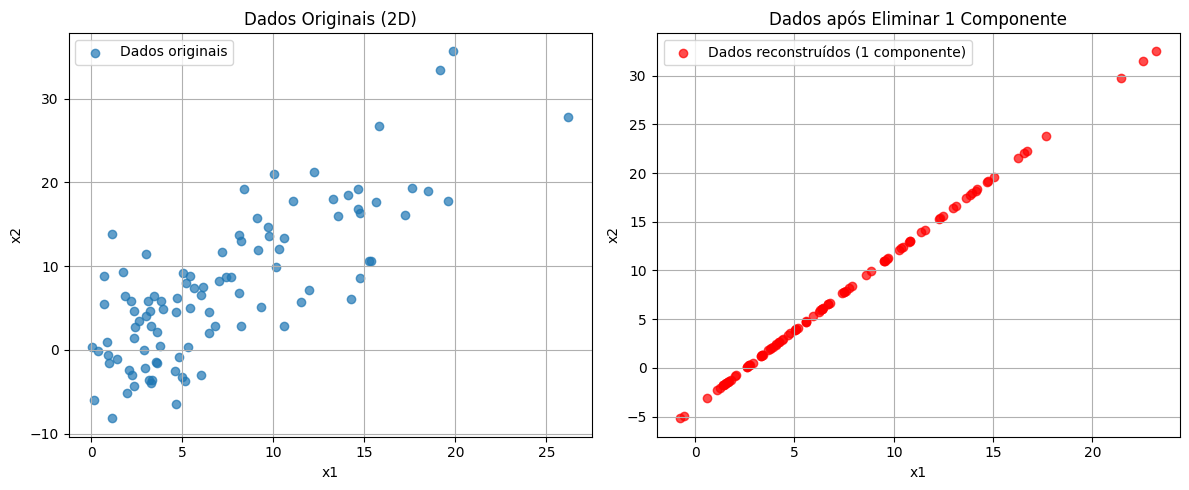

In [20]:
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

pca_reduced = PCA(n_components=1)
X_pca_reduced = pca_reduced.fit_transform(X)
X_reconstructed = pca_reduced.inverse_transform(X_pca_reduced)

plt.figure(figsize=(12, 5))

# Plot dos dados originais
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, label='Dados originais')
plt.title('Dados Originais (2D)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()

# Plot após eliminar 1 componente
plt.subplot(1, 2, 2)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.7,
            color='red', label='Dados reconstruídos (1 componente)')
plt.title('Dados após Eliminar 1 Componente')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Explicando a variância
print(f"Variância explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variância explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")

Variância explicada por PC1: 89.44%
Variância explicada por PC2: 10.56%


In [22]:
resultado = np.array([3, 4]) @ np.array([[4, 2], [-1, 2]])  # Note a vírgula entre as linhas!
print(resultado)

[ 8 14]
